Cell 1: load data

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.config import PROCESSED_DIR, REPORTS_DIR, TARGET

sns.set_theme(style="whitegrid")
train = pd.read_csv(PROCESSED_DIR / "train.csv")
print(train.shape)
train.head()

(119999, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.114987,62,0.0,10.000000,NaN,5,0.0,1,0.0,2.0
1,0,0.666105,46,0.0,0.419041,7404.0,3,0.0,1,0.0,3.0
2,0,0.214501,32,0.0,0.211999,3716.0,8,0.0,0,0.0,2.0
3,0,0.030495,32,0.0,0.022753,69000.0,8,0.0,1,0.0,0.0
4,0,0.110935,50,0.0,10.000000,NaN,8,0.0,1,0.0,0.0


Cell 2: class balance

Default rate: 6.68%


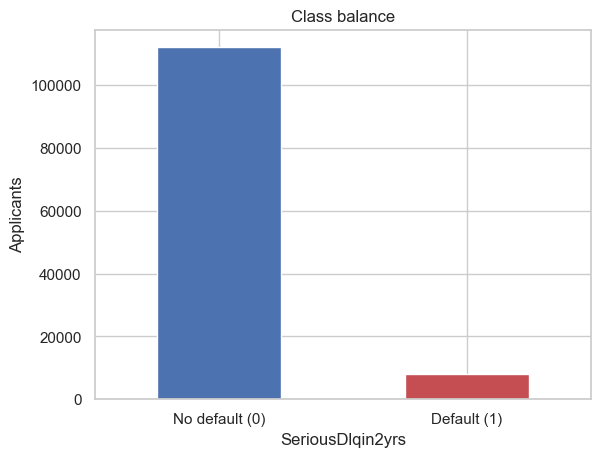

In [2]:
print(f"Default rate: {train[TARGET].mean():.2%}")

ax = train[TARGET].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
ax.set_title("Class balance")
ax.set_ylabel("Applicants")
plt.savefig(REPORTS_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 3: missing values

In [3]:
missing = train.isna().mean().mul(100).round(2)
missing[missing > 0].sort_values(ascending=False)

MonthlyIncome                           19.79
NumberOfDependents                       2.62
NumberOfTime30-59DaysPastDueNotWorse     0.18
NumberOfTimes90DaysLate                  0.18
NumberOfTime60-89DaysPastDueNotWorse     0.18
dtype: float64

Cell 4: default rate by age

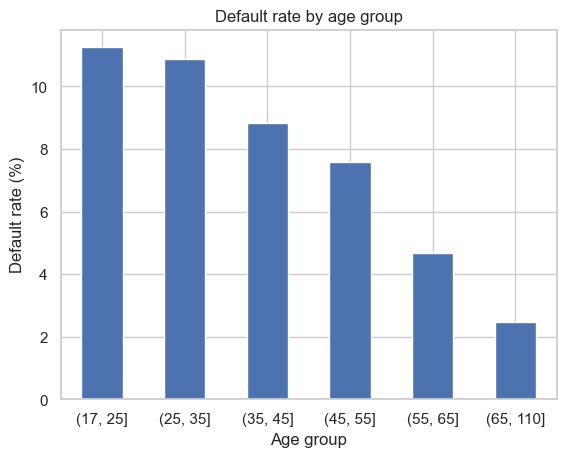

In [4]:
age_group = pd.cut(train["age"], bins=[17, 25, 35, 45, 55, 65, 110])
by_age = train.groupby(age_group, observed=True)[TARGET].mean() * 100

ax = by_age.plot(kind="bar", color="#4C72B0")
ax.set_title("Default rate by age group")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Age group")
plt.xticks(rotation=0)
plt.savefig(REPORTS_DIR / "default_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 5: default rate by late payments

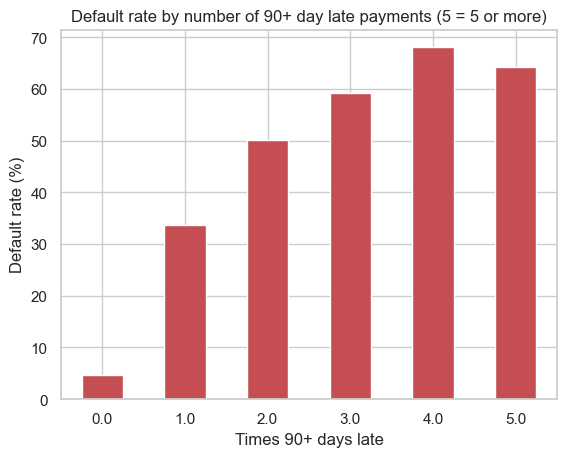

In [5]:
late = train["NumberOfTimes90DaysLate"].clip(upper=5)
by_late = train.groupby(late)[TARGET].mean() * 100

ax = by_late.plot(kind="bar", color="#C44E52")
ax.set_title("Default rate by number of 90+ day late payments (5 = 5 or more)")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Times 90+ days late")
plt.xticks(rotation=0)
plt.savefig(REPORTS_DIR / "default_by_late.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 6: correlation with default

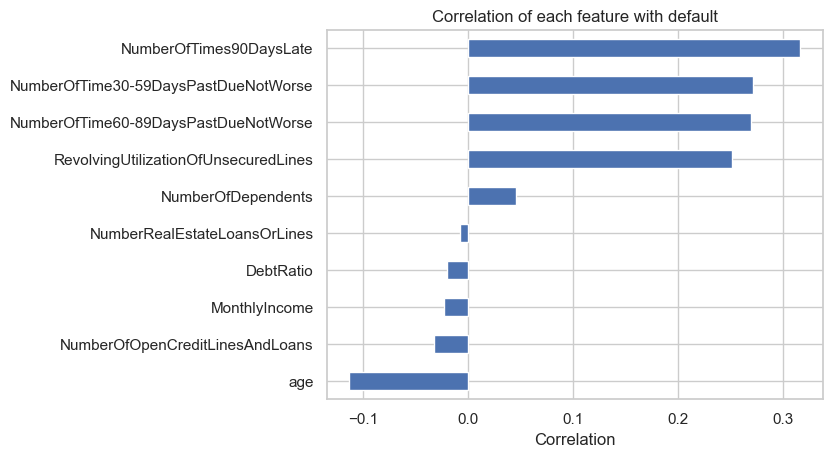

In [6]:
corr = train.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

ax = corr.plot(kind="barh", color="#4C72B0")
ax.set_title("Correlation of each feature with default")
ax.set_xlabel("Correlation")
plt.savefig(REPORTS_DIR / "correlations.png", dpi=150, bbox_inches="tight")
plt.show()